<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Stochastic-modeling-and-derivatives---TD3---corrigé" data-toc-modified-id="Stochastic-modeling-and-derivatives---TD3---corrigé-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Stochastic modeling and derivatives - TD3 - corrigé</a></span><ul class="toc-item"><li><span><a href="#Exercice-:-Pricing-d'options-américaines-dans-le-modèle-binomial" data-toc-modified-id="Exercice-:-Pricing-d'options-américaines-dans-le-modèle-binomial-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Exercice : Pricing d'options américaines dans le modèle binomial</a></span><ul class="toc-item"><li><span><a href="#Implémentation-de-l'équation-rétrograde-américaine" data-toc-modified-id="Implémentation-de-l'équation-rétrograde-américaine-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Implémentation de l'équation rétrograde américaine</a></span></li><li><span><a href="#Le-cas-du-call" data-toc-modified-id="Le-cas-du-call-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Le cas du call</a></span></li><li><span><a href="#Le-cas-du-put" data-toc-modified-id="Le-cas-du-put-1.1.3"><span class="toc-item-num">1.1.3&nbsp;&nbsp;</span>Le cas du put</a></span></li></ul></li></ul></li></ul></div>

# Stochastic modeling and derivatives - TD3 - corrigé

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Exercice : Pricing d'options américaines dans le modèle binomial

$\bullet$ $P_{t_i} = $ prix d'une option américaine de maturité $t_n$ et de payoff $\Psi(\cdot)$ dans le modèle binomial 

$\bullet$ Equation de programmation dynamique
$$
\begin{aligned}
&P_{t_n} = \Psi(S_{t_n})
\\
&P_{t_i} = \max \left( \Psi(S_{t_i}), \, \mathbb{E}^{\mathbb{Q}} \Bigl[ \frac 1{1+r} P_{t_{i+1}} \Big| S_{t_i} \Bigr] \right),
\qquad i = 0, 1, \dotsm n-1,
\end{aligned}
$$
où $\mathbb{Q}$ est la mesure risque-neutre du modèle binomial.

$\bullet$ Alternativement, on peut écrire l'équation de programmation dynamique directement pour la fonction de prix de l'option $v_{\mathrm{Am}}(t_i, \cdot)$:

\begin{equation}
\begin{aligned} 
&v_{\mathrm{Am}}(t_n, S) = \Psi(S)
\\
&v_{\mathrm{Am}}(t_i, S) = \max \left( \Psi(S), \frac 1{1+r} \Bigl( v_{\mathrm{Am}}(t_{i+1}, S \, u) \, q^{\mathrm{up}} + v_{\mathrm{Am}}(t_{i+1}, S \, d) \, q^{\mathrm{down}} \Bigr) \right),
\qquad i = 0, 1, \dotsm n-1.
\end{aligned}
\end{equation}

On remarquera que l'on a remplacé l'espérance conditionnelle $\mathbb{E}^{\mathbb{Q}} \Bigl[ \frac 1{1+r} P_{t_{i+1}} \Big| S_{t_i} \Bigr]$ avec son expression explicite dans le modèle binomial (faisant apparaitre $q^{\mathrm{up}}, q^{\mathrm{down}}$).

$\bullet$ Remarque: l'équation ci-dessus a la même nature que la récursion pour l'option européenne (TP2). La seule différence est que, maintenant, on prend à chaque date le $\max$ entre l'actualisation de $v_{\mathrm{Am}}(t_{i+1}, \cdot)$ et le payoff $\Psi$.

### Implémentation de l'équation rétrograde américaine

Nous travaillons sur l'équation de programmation dynamique pour la fonction $v_{\mathrm{Am}}$.

$\bullet$ Comme dans le cas de l'option européenne, on veut créer une fonction Python qui effectue l'itération pour l'option américaine de l'étape $i+1$ à l'étape $i$:

In [2]:
def recursion_americaine(r, u, d, payoff, fonction_prix_t_i_plus_one):
    """
    On effectue une itération dans l'équation de programmation dynamique de la date t_{i+1} à la date t_i.
    
    Paramètres
    + r, u, d: les paramètres du modèle binomial 
    
    + payoff (fonction Python): la fonction payoff de l'opt américaine
    
    + fonction_prix_t_i_plus_one (fonction Python): la fonction de prix v_{Am}(t_{i+1}, .) de l'opt américaine à la date t_{i+1}.
      Cette fonction doit prendre comme argument la valeur S_{t_{i+1}} du sous-jacent.
    
    Output: une fonction Python, la fonction de prix v_{Am}(t_i, .) de l'opt américaine à la date t_i.
            Cette fonction prendra comme argument la valeur S_{t_i} du sous-jacent.
    """
    q_up = (1 + r - d) / (u-d)
    q_down = 1 - q_up
    
    def fonction_prix_t_i(S):
        ########################################################
        ## TO DO: compléter avec l'itération de t_{i+1} à t_i
        ########################################################
        valeur_continuation = (fonction_prix_t_i_plus_one(S*u) * q_up + fonction_prix_t_i_plus_one(S*d) * q_down) / (1 + r)
        
        valeur = np.maximum(payoff(S), valeur_continuation)
        
        return valeur
    
    return fonction_prix_t_i

$\bullet$ Ensuite, on procède de manière rétrograde pour calculer le prix en $t_i$ pour $0 \le i < n$ de l'option américaine de payoff $\Psi(.)$ et maturité $t_n$.

In [3]:
def prix_americain_t_i(r, u, d, payoff, i, n):
    """
    Prix à la date t_i, i < n, de l'option américaine de maturité t_n et de fct de payoff donnée.
    
    Output: une fonction Python, la fonction de prix v_{Am}(t_i, .) à la date t_i.
            Cette fonction prendra comme argument la valeur S_{t_i} du sous-jacent.
    """
    fonction_prix = payoff    
    
    for j in range (i, n):
        
        ########################################################
        ## TO DO: compléter avec le calcul de la fonction de prix
        ## à la date t_i
        ########################################################
        fonction_prix = recursion_americaine(r, u, d, payoff, fonction_prix)
    
    return fonction_prix

### Le cas du call

$\bullet$ Comparer le résultats pour l'option européenne et l'option américaine dans le cas du payoff du call $\Psi(S) = (S - K)^+$.

In [11]:
n = 8
i = 0

S_0 = 100.36; u = 1.1335; d = 1.0/1.178; r = 0.0088; K = 100.40

assert(d < 1 + r < u)

def payoff_call(S):
    return np.maximum(S - K, 0)

########################################################
## TO DO: compléter avec les calculs des prix 
## européen et américain
########################################################

from opt_europeenne_mod_binomial import recursion, recursion_n_i

## Prix européen
fonction_prix_eur = recursion_n_i(r, u, d, payoff_call, i, n)

prix_eur = fonction_prix_eur(S_0)

## Prix américain
fonction_prix_am = prix_americain_t_i(r, u, d, payoff_call, i, n)

prix_am = fonction_prix_am(S_0)

print("Prix en t_%1.0f du call europeen de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.3f: %1.3f" %(i, n, K, i, S_0, prix_eur))

print("Prix en t_%1.0f du call americain de payoff (S_{t_%1.0f} - %1.1f)^+ lorsque S_{t_%1.0f} = %1.3f: %1.3f" %(i, n, K, i, S_0, prix_am))


Prix en t_0 du call europeen de payoff (S_{t_8} - 100.4)^+ lorsque S_{t_0} = 100.360: 19.546
Prix en t_0 du call americain de payoff (S_{t_8} - 100.4)^+ lorsque S_{t_0} = 100.360: 19.546


Vos résultats sont-ils conformes à la théorie?

### Le cas du put

$\bullet$ Même test dans le cas du payoff du put $\Psi(S) = (K - S)^+$: comparer les prix de l'option européenne et de l'option américaine.

In [5]:
n = 5
i = 0

def payoff_put(S):
    return np.maximum(K - S, 0)

########################################################
## TO DO: compléter avec les calculs des prix 
## européen et américain
########################################################

## Prix européen
fonction_prix_eur = recursion_n_i(r, u, d, payoff_put, i, n)

prix_eur = fonction_prix_eur(S_0)

## Prix américain
fonction_prix_am = prix_americain_t_i(r, u, d, payoff_put, i, n)

prix_am = fonction_prix_am(S_0)

print("Prix en t_%1.0f du put europeen de payoff (%1.1f - S_{t_%1.0f})^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, K, n, i, S_0, prix_eur))

print("Prix en t_%1.0f du put americain de payoff (%1.1f - S_{t_%1.0f})^+ lorsque S_{t_%1.0f} = %1.1f: %1.2f" %(i, K, n, i, S_0, prix_am))


Prix en t_0 du put europeen de payoff (120.0 - S_{t_5})^+ lorsque S_{t_0} = 100.0: 23.12
Prix en t_0 du put americain de payoff (120.0 - S_{t_5})^+ lorsque S_{t_0} = 100.0: 26.19


In [6]:
## Une grille de 100 valeurs du sous-jacent S_0 entre K/3 et 2*K
nb_points = 100
spots = np.linspace(K/3, 2*K, nb_points)

put_prices_eur = np.zeros(nb_points)

put_prices_am = np.zeros(nb_points)

## Les fonctions de prix du put européen et du put américain 
## de strike K = 120 ont déjà été définies plus haut    

for j, S in enumerate(spots):
    ########################################################
    ## TO DO: compléter avec les calculs des prix 
    ## européen et américain
    ########################################################
    put_prices_eur[j] = fonction_prix_eur(S)
    
    put_prices_am[j] = fonction_prix_am(S)

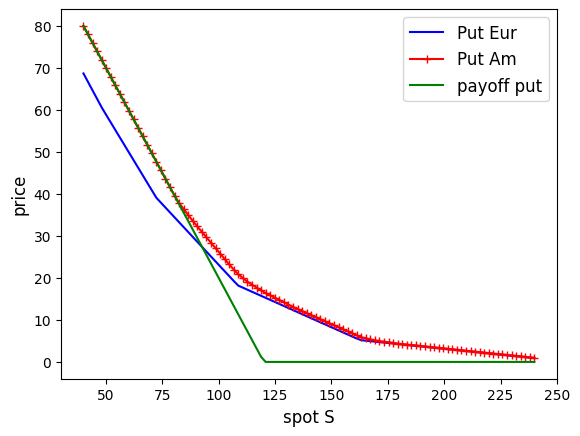

In [7]:
########################################################
## TO DO: compléter avec l'affichage des prix européen
## et américain en fonction des valeurs du spot
########################################################
plt.plot(spots, put_prices_eur, color="b", label="Put Eur")
plt.plot(spots, put_prices_am, color="r", marker="+", label="Put Am")

## On affiche le payoff
plt.plot(spots, payoff_put(spots), color="g", label="payoff put")

plt.xlabel("spot S", fontsize=12)
plt.ylabel("price", fontsize=12)

_=plt.legend(loc="best", fontsize=12)

### Région d'exercice
Elle est définie à l'instant $t_i$ par
$${\cal E}_{t_i}=\{S: v(t_i,S)=\Psi(S)\}.$$
Et il est commode de représenter l'ensemble des ${\cal E}_{t_i}$ pour les différentes dates pour savoir dans quelle configuration sous la forme de (temps, spot) il est optimal d'exercer.

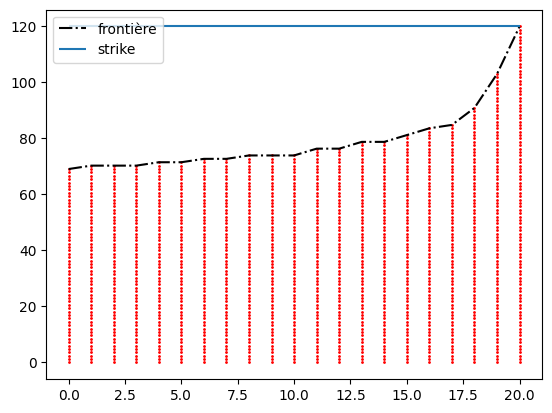

In [9]:
n=20
frontiere_exercice=[]
grille_spot_exercice = np.linspace(0, K, 100) # on n'exerce jamais au dessus du strike car le payoff est nul
for i in range(n+1):
    fonction_prix_am = prix_americain_t_i(r, u, d, payoff_put, i, n)
    prix_am = fonction_prix_am(grille_spot_exercice)
    payoffs = payoff_put(grille_spot_exercice)
    spot_region_exercice=grille_spot_exercice[prix_am==payoffs]
    frontiere_exercice.append(np.max(spot_region_exercice))
    plt.scatter(np.zeros(spot_region_exercice.size)+i, spot_region_exercice, color="red", marker="o" , s=1)
plt.plot(range(n+1), frontiere_exercice, label="frontière", color="black", ls="-.")
plt.hlines(y=K, xmin=0, xmax=n, label='strike')
_=plt.legend()